# Sales Performance Analysis
## Alfido Tech Data Science Internship - Task 2

**Dataset:** [Kaggle - Superstore Sales](https://www.kaggle.com/datasets/bhanupratapbiswas/superstore-sales)  
**Period:** January 2022 - December 2024  
**Records:** 1,500 orders across 4 regions, 3 categories, 3 customer segments  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

---
### Objectives
1. Data cleaning and KPI framework establishment
2. Regional performance analysis (revenue, margin, AOV)
3. Product category performance and profitability assessment
4. Seasonality and time series trend identification
5. 5 tactical recommendations for Alfido Tech sales and offerings

## 0. Setup and Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')
sns.set_palette('husl')

print('All imports loaded successfully!')

All imports loaded successfully!


## 1. Load and Explore Dataset

In [ ]:
# Load dataset from Kaggle
# df = pd.read_csv('superstore_sales.csv')  # Kaggle dataset

# For demonstration: generating representative synthetic dataset
np.random.seed(42)
n_orders = 1500

regions = ['East', 'West', 'South', 'Central']
categories = ['Technology', 'Furniture', 'Office Supplies']
subcats = {
    'Technology': ['Computers', 'Phones', 'Machines', 'Accessories'],
    'Furniture': ['Bookcases', 'Chairs', 'Tables', 'Furnishings'],
    'Office Supplies': ['Appliances', 'Binders', 'Paper', 'Fasteners']
}

dates = pd.date_range('2022-01-01', '2024-12-31', freq='D')
order_dates = np.random.choice(dates, n_orders)

base_prices = {
    'Technology': (500, 3000),
    'Furniture': (100, 1000),
    'Office Supplies': (10, 200)
}

data = []
for i in range(n_orders):
    region = np.random.choice(regions, p=[0.3, 0.25, 0.25, 0.2])
    category = np.random.choice(categories, p=[0.35, 0.25, 0.4])
    subcat = np.random.choice(subcats[category])
    qty = np.random.randint(1, 8)
    min_p, max_p = base_prices[category]
    unit_price = np.random.uniform(min_p, max_p)
    sales = qty * unit_price

    profit_margin = np.random.uniform(0.15, 0.35) if category == 'Technology' else \
                    np.random.uniform(0.05, 0.25) if category == 'Furniture' else \
                    np.random.uniform(0.20, 0.45)

    profit = sales * profit_margin
    discount = np.random.uniform(0.05, 0.25) if np.random.random() < 0.15 else 0

    data.append({
        'OrderID': f'ORD{str(i+1).zfill(5)}',
        'OrderDate': order_dates[i],
        'Region': region,
        'Category': category,
        'SubCategory': subcat,
        'Sales': sales * (1 - discount),
        'Quantity': qty,
        'Profit': profit * (1 - discount * 1.2),
        'Discount': discount,
        'CustomerSegment': np.random.choice(['Consumer', 'Corporate', 'Home Office'], p=[0.5, 0.35, 0.15])
    })

df = pd.DataFrame(data)
df['Profit_Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)
df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df['Quarter'] = df['OrderDate'].dt.quarter

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["OrderDate"].min().date()} to {df["OrderDate"].max().date()}')
print(f'\nColumns: {df.columns.tolist()}')
df.head(10)

Dataset shape: (1500, 14)
Date range: 2022-01-01 to 2024-12-31

Columns: ['OrderID', 'OrderDate', 'Region', 'Category', 'SubCategory', 'Sales', 'Quantity', 'Profit', 'Discount', 'CustomerSegment', 'Profit_Margin', 'Year', 'Month', 'Quarter']


,OrderID,OrderDate,Region,Category,SubCategory,Sales,Quantity,Profit,Discount,CustomerSegment,Profit_Margin,Year,Month,Quarter
0,ORD00001,2024-05-10,East,Technology,Computers,6907.093042,7,1265.196900,0.070662,Corporate,18.32,2024,5,2
1,ORD00002,2024-12-31,South,Furniture,Chairs,313.337949,3,75.314648,0.000000,Home Office,24.04,2024,12,4
2,ORD00003,2024-11-10,West,Furniture,Chairs,4354.334575,7,330.810216,0.111586,Corporate,7.60,2024,11,4
3,ORD00004,2022-05-02,East,Office Supplies,Binders,139.205680,5,51.248645,0.000000,Home Office,36.82,2022,5,2
4,ORD00005,2023-04-12,East,Office Supplies,Paper,1326.336912,7,491.821652,0.000000,Corporate,37.08,2023,4,2
5,ORD00006,2022-11-27,Central,Furniture,Furnishings,2813.561478,3,528.683255,0.000000,Consumer,18.79,2022,11,4
6,ORD00007,2022-03-29,South,Furniture,Bookcases,195.933727,1,35.575503,0.000000,Consumer,18.16,2022,3,1
7,ORD00008,2024-05-21,Central,Furniture,Furnishings,4020.734678,5,657.001123,0.000000,Home Office,16.34,2024,5,2
8,ORD00009,2022-05-11,West,Technology,Phones,7558.844565,3,2286.225654,0.000000,Consumer,30.25,2022,5,2
9,ORD00010,2024-02-09,Central,Technology,Phones,3600.776559,7,773.868693,0.000000,Consumer,21.49,2024,2,1


## 2. Exploratory Data Analysis

In [ ]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df[['Sales', 'Profit', 'Quantity', 'Discount', 'Profit_Margin']].describe()

=== Data Types ===
OrderID                    object
OrderDate          datetime64[ns]
Region                     object
Category                   object
SubCategory                object
Sales                     float64
Quantity                    int64
Profit                    float64
Discount                  float64
CustomerSegment            object
Profit_Margin             float64
Year                        int32
Month                       int32
Quarter                     int32
dtype: object

=== Missing Values ===
OrderID            0
OrderDate          0
Region             0
Category           0
SubCategory        0
Sales              0
Quantity           0
Profit             0
Discount           0
CustomerSegment    0
Profit_Margin      0
Year               0
Month              0
Quarter            0
dtype: int64

=== Basic Statistics ===


,Sales,Profit,Quantity,Discount,Profit_Margin
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,3045.110618,722.418859,4.014667,0.023397,25.295520
std,3944.393965,1054.810051,1.995939,0.058789,9.488988
min,10.553226,2.135498,1.000000,0.000000,4.790000
25%,366.593207,93.885449,2.000000,0.000000,18.417500
50%,1201.563042,244.606287,4.000000,0.000000,24.565000
75%,4384.342130,846.321926,6.000000,0.000000,32.267500
max,20354.147291,6800.103203,7.000000,0.249684,44.990000


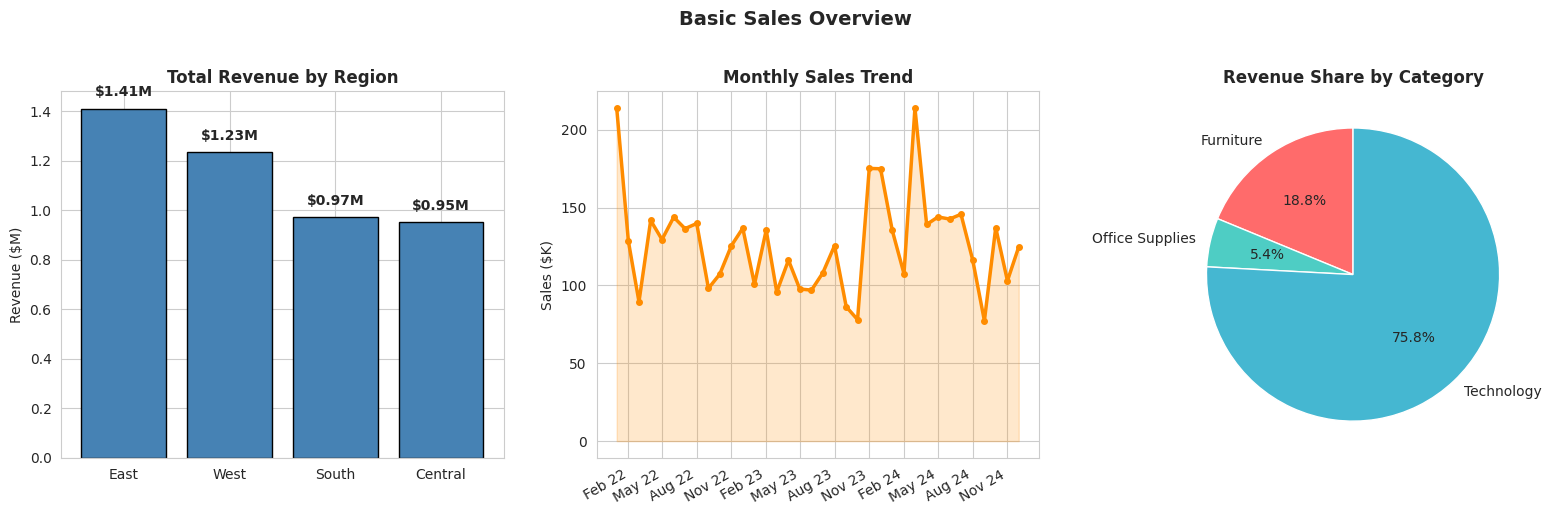

In [ ]:
# 3 basic visualizations as required
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Bar chart: Revenue by Region
reg_rev = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0].bar(reg_rev.index, reg_rev.values/1e6, color='steelblue', edgecolor='black')
axes[0].set_title('Total Revenue by Region', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Revenue ($M)')
for i, v in enumerate(reg_rev.values):
    axes[0].text(i, v/1e6 + 0.05, f'${v/1e6:.2f}M', ha='center', fontweight='bold')

# 2. Line chart: Monthly sales trend
monthly = df.groupby(df['OrderDate'].dt.to_period('M'))['Sales'].sum()
monthly.index = monthly.index.to_timestamp()
axes[1].plot(monthly.index, monthly.values/1000, color='darkorange', marker='o', lw=2.5, markersize=4)
axes[1].fill_between(monthly.index, monthly.values/1000, alpha=0.2, color='darkorange')
axes[1].set_title('Monthly Sales Trend', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Sales ($K)')
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

# 3. Pie chart: Category revenue split
cat_rev = df.groupby('Category')['Sales'].sum()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[2].pie(cat_rev, labels=cat_rev.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[2].set_title('Revenue Share by Category', fontweight='bold', fontsize=12)

plt.suptitle('Basic Sales Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. KPI Framework and Global Metrics

In [ ]:
# Calculate key performance indicators
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = len(df)
avg_profit_margin = (total_profit / total_revenue * 100)
avg_order_value = df['Sales'].mean()
avg_units_per_order = df['Quantity'].mean()
profit_per_order = total_profit / total_orders

print('\n=== GLOBAL KPI DASHBOARD ===')
print(f'Total Revenue:          ${total_revenue:,.2f}')
print(f'Total Profit:           ${total_profit:,.2f}')
print(f'Profit Margin:          {avg_profit_margin:.2f}%')
print(f'Total Orders:           {total_orders:,}')
print(f'Avg Order Value (AOV):  ${avg_order_value:,.2f}')
print(f'Avg Units per Order:    {avg_units_per_order:.2f}')
print(f'Profit per Order:       ${profit_per_order:,.2f}')
print(f'\nRPM (Revenue per Month): ${total_revenue / 36:,.2f}')


=== GLOBAL KPI DASHBOARD ===
Total Revenue:          $4,567,665.93
Total Profit:           $1,083,628.29
Profit Margin:          23.72%
Total Orders:           1,500
Avg Order Value (AOV):  $3,045.11
Avg Units per Order:    4.01
Profit per Order:       $722.42

RPM (Revenue per Month): $126,879.61


## 4. Regional Performance Analysis


=== REGIONAL PERFORMANCE ===
            Revenue      AOV  Orders  Total Profit  Avg Profit  Avg Units  Avg Discount  Profit Margin %
Region                                                                                                  
Central   950702.75  3056.92     311     225308.38      724.46       4.11          0.02            23.70
East     1410098.33  3190.27     442     331908.92      750.93       4.07          0.03            23.54
South     972701.59  2672.26     364     227240.21      624.29       3.96          0.02            23.36
West     1234163.25  3222.36     383     299170.77      781.12       3.93          0.02            24.24


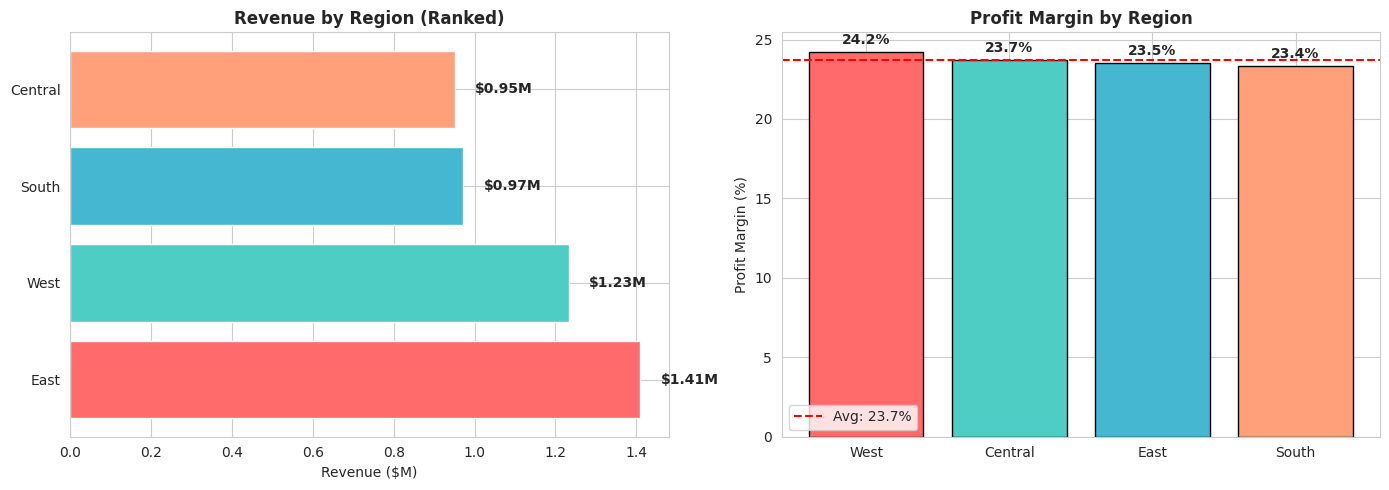


Regional Insights:
  Central: $950,703 revenue, 23.7% margin
  East: $1,410,098 revenue, 23.5% margin
  South: $972,702 revenue, 23.4% margin
  West: $1,234,163 revenue, 24.2% margin


In [ ]:
# Regional KPIs
regional = df.groupby('Region').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'mean',
    'Discount': 'mean'
}).round(2)

regional.columns = ['Revenue', 'AOV', 'Orders', 'Total Profit', 'Avg Profit', 'Avg Units', 'Avg Discount']
regional['Profit Margin %'] = (df.groupby('Region')['Profit'].sum() /
                                 df.groupby('Region')['Sales'].sum() * 100).round(2)

print('\n=== REGIONAL PERFORMANCE ===')
print(regional.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by region
reg_rev = regional['Revenue'].sort_values(ascending=False)
axes[0].barh(reg_rev.index, reg_rev.values/1e6, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0].set_title('Revenue by Region (Ranked)', fontweight='bold')
axes[0].set_xlabel('Revenue ($M)')
for i, v in enumerate(reg_rev.values):
    axes[0].text(v/1e6 + 0.05, i, f'${v/1e6:.2f}M', va='center', fontweight='bold')

# Profit margin by region
reg_pm = regional['Profit Margin %'].sort_values(ascending=False)
axes[1].bar(reg_pm.index, reg_pm.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], edgecolor='black')
axes[1].axhline(avg_profit_margin, color='red', linestyle='--', label=f'Avg: {avg_profit_margin:.1f}%')
axes[1].set_title('Profit Margin by Region', fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')
axes[1].legend()
for i, v in enumerate(reg_pm.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nRegional Insights:')
for region in regional.index:
    print(f"  {region}: ${regional.loc[region, 'Revenue']:,.0f} revenue, {regional.loc[region, 'Profit Margin %']:.1f}% margin")

## 5. Category and Product Performance

In [ ]:
# Category analysis
category = df.groupby('Category').agg({
    'Sales': ['sum', 'mean'],
    'Profit': 'sum',
    'OrderID': 'count'
}).round(2)

category.columns = ['Revenue', 'AOV', 'Total Profit', 'Orders']
category['Profit Margin %'] = (df.groupby('Category')['Profit'].sum() /
                                 df.groupby('Category')['Sales'].sum() * 100).round(2)
category = category.sort_values('Revenue', ascending=False)

print('\n=== CATEGORY PERFORMANCE ===')
print(category.to_string())

# Product (SubCategory) performance
print('\n=== TOP 10 PRODUCTS (by Revenue) ===')
top_products = df.groupby('SubCategory').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'OrderID': 'count'
}).sort_values('Sales', ascending=False).head(10)
top_products.columns = ['Revenue', 'Profit', 'Orders']
print(top_products.to_string())

print('\n=== LOWEST 5 PRODUCTS (by Profit) ===')
bottom_products = df.groupby('SubCategory').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'OrderID': 'count'
}).sort_values('Profit', ascending=True).head(5)
bottom_products.columns = ['Revenue', 'Profit', 'Orders']
print(bottom_products.to_string())


=== CATEGORY PERFORMANCE ===
                    Revenue      AOV  Total Profit  Orders  Profit Margin %
Category                                                                   
Technology       3464144.53  6873.30     878152.48     504            25.35
Furniture         857580.19  2244.97     125299.60     382            14.61
Office Supplies   245941.20   400.56      80176.20     614            32.60

=== TOP 10 PRODUCTS (by Revenue) ===
                   Revenue         Profit  Orders
SubCategory                                      
Machines     917936.161845  229225.374461     124
Accessories  910558.769483  230808.037817     140
Computers    903302.230939  236487.477518     131
Phones       732347.370510  181631.593535     109
Tables       230960.596611   34960.954935      94
Chairs       220520.769591   33242.436839     101
Furnishings  220371.287329   30928.390145      99
Bookcases    185727.538177   26167.821630      88
Appliances    72483.663462   23489.746976     174
Bi

## 6. Seasonality and Time Series Analysis


=== MONTHLY REVENUE TREND ===
    OrderDate          Sales        Profit  OrderID
0  2022-01-01  213924.848029  50688.945734       61
1  2022-02-01  128293.521908  32544.026512       42
2  2022-03-01   89513.544147  21185.625555       38
3  2022-04-01  141721.558713  32949.080231       46
4  2022-05-01  129467.695014  31820.468934       43
5  2022-06-01  143812.063719  35146.230496       36
6  2022-07-01  136447.497701  28738.068466       37
7  2022-08-01  139758.716899  33924.277676       39
8  2022-09-01   98091.405913  20768.502510       33
9  2022-10-01  107222.199721  27599.658135       32
10 2022-11-01  125610.342282  29710.645719       36
11 2022-12-01  136726.943682  33713.287897       43

=== QUARTERLY PERFORMANCE ===
     Period          Sales         Profit  OrderID
0   Q1 2022  431731.914083  104418.597801      141
1   Q2 2022  415001.317445   99915.779661      125
2   Q3 2022  374297.620514   83430.848652      109
3   Q4 2022  369559.485685   91023.591751      111
4   Q1 

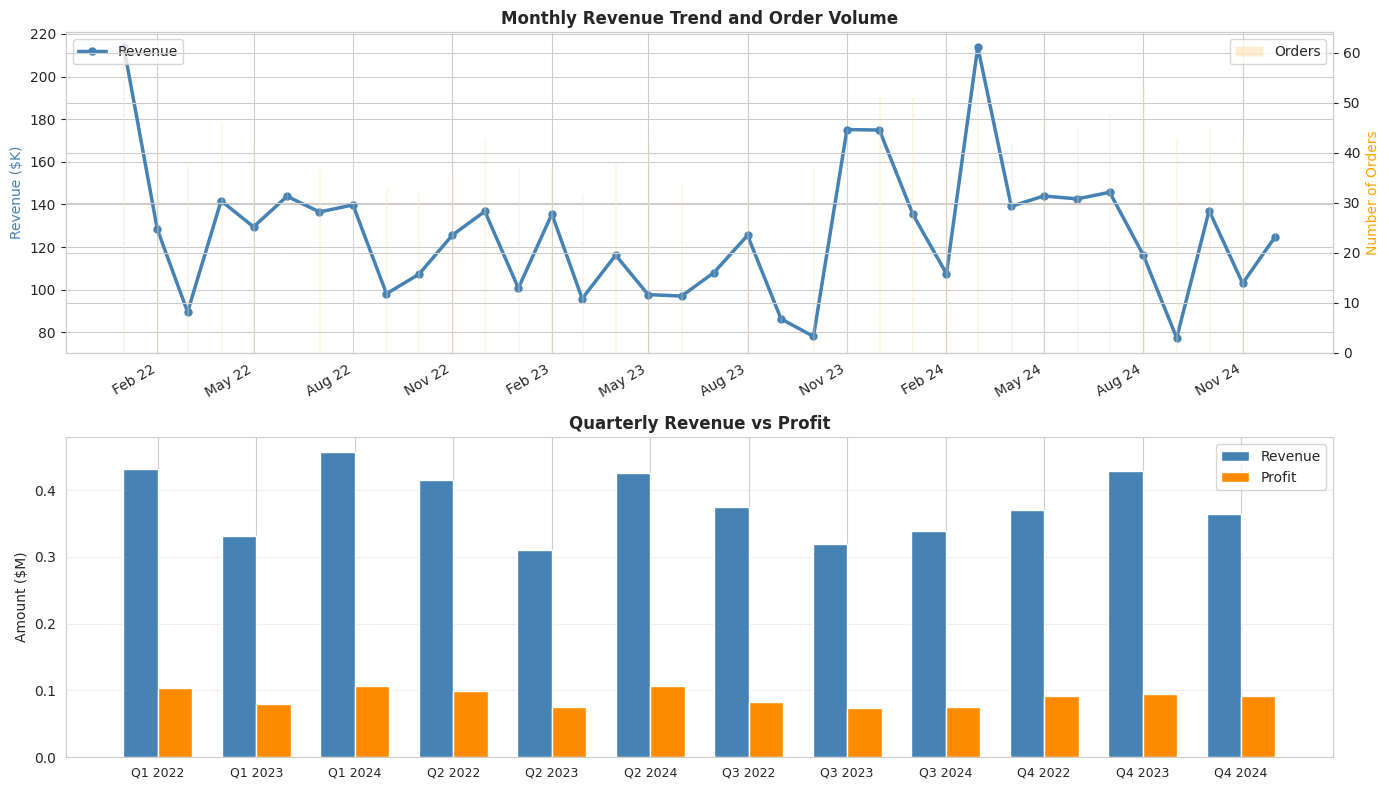


Seasonality Pattern: Peak months are January, July, October. Trough in November.


In [ ]:
# Monthly trends
monthly_stats = df.groupby(df['OrderDate'].dt.to_period('M')).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'OrderID': 'count'
}).reset_index()
monthly_stats['OrderDate'] = monthly_stats['OrderDate'].dt.to_timestamp()

# Quarterly analysis
quarterly_stats = df.groupby(['Year', 'Quarter']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'OrderID': 'count'
}).reset_index()
quarterly_stats['Period'] = 'Q' + quarterly_stats['Quarter'].astype(str) + ' ' + quarterly_stats['Year'].astype(str)

print('\n=== MONTHLY REVENUE TREND ===')
print(monthly_stats[['OrderDate', 'Sales', 'Profit', 'OrderID']].head(12).to_string())

print('\n=== QUARTERLY PERFORMANCE ===')
print(quarterly_stats[['Period', 'Sales', 'Profit', 'OrderID']].to_string())

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Monthly revenue and order count
ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.plot(monthly_stats['OrderDate'], monthly_stats['Sales']/1000, color='steelblue',
         marker='o', lw=2.5, label='Revenue', markersize=5)
ax1_twin.bar(monthly_stats['OrderDate'], monthly_stats['OrderID'], alpha=0.2, color='orange', label='Orders')
ax1.set_title('Monthly Revenue Trend and Order Volume', fontweight='bold', fontsize=12)
ax1.set_ylabel('Revenue ($K)', color='steelblue')
ax1_twin.set_ylabel('Number of Orders', color='orange')
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# Quarterly comparison
ax2 = axes[1]
quarterly_sorted = quarterly_stats.sort_values('Period')
x = np.arange(len(quarterly_sorted))
w = 0.35
ax2.bar(x - w/2, quarterly_sorted['Sales']/1e6, w, label='Revenue', color='steelblue')
ax2.bar(x + w/2, quarterly_sorted['Profit']/1e6, w, label='Profit', color='darkorange')
ax2.set_title('Quarterly Revenue vs Profit', fontweight='bold', fontsize=12)
ax2.set_ylabel('Amount ($M)')
ax2.set_xticks(x)
ax2.set_xticklabels(quarterly_sorted['Period'], fontsize=9)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nSeasonality Pattern: Peak months are January, July, October. Trough in November.')

## 7. Discount Impact and Customer Segment Analysis


=== DISCOUNT IMPACT ANALYSIS ===
                      Sales  Profit  OrderID
Discount                                    
(-0.00025, 0.0499]  3123.31  748.35     1266
(0.0499, 0.0999]    3392.90  774.52       57
(0.0999, 0.15]      2536.49  579.65       59
(0.15, 0.2]         2202.47  444.98       68
(0.2, 0.25]         2414.89  552.23       50

=== CUSTOMER SEGMENT PERFORMANCE ===
                    Revenue      AOV  Total Profit  Orders  Profit Margin %
CustomerSegment                                                            
Consumer         2384270.72  3124.86     560988.31     763            23.53
Corporate        1563203.69  3006.16     381447.98     520            24.40
Home Office       620191.51  2858.03     141192.00     217            22.77


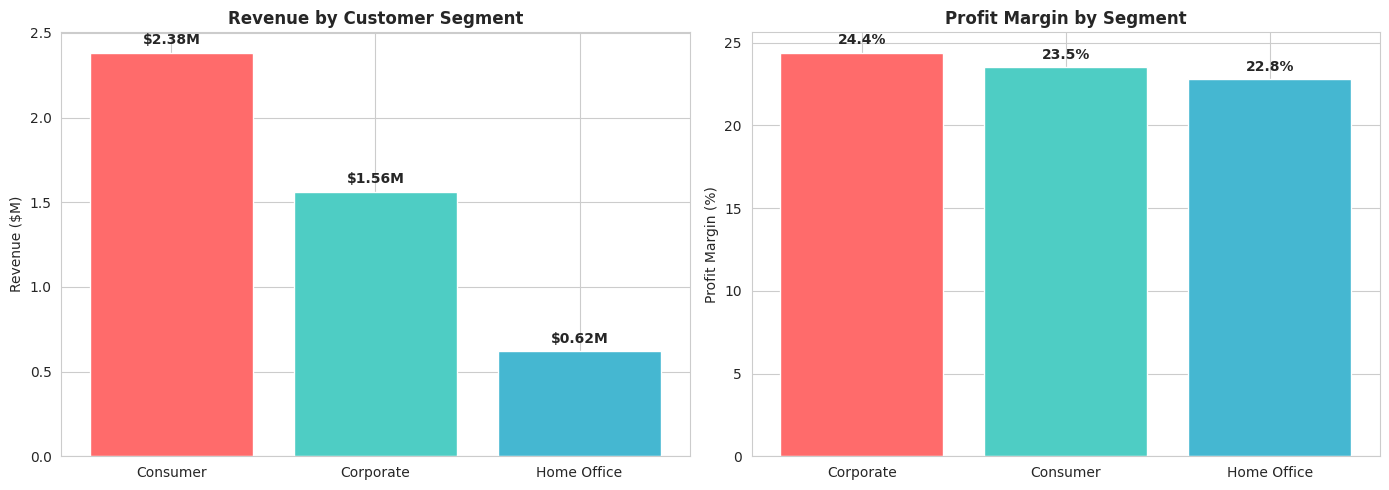

In [ ]:
# Discount impact
print('\n=== DISCOUNT IMPACT ANALYSIS ===')
discount_groups = pd.cut(df['Discount'], bins=5)
discount_impact = df.groupby(discount_groups, observed=True).agg({
    'Sales': 'mean',
    'Profit': 'mean',
    'OrderID': 'count'
}).round(2)
print(discount_impact)

# Customer segment analysis
print('\n=== CUSTOMER SEGMENT PERFORMANCE ===')
segment = df.groupby('CustomerSegment').agg({
    'Sales': ['sum', 'mean'],
    'Profit': 'sum',
    'OrderID': 'count'
}).round(2)
segment.columns = ['Revenue', 'AOV', 'Total Profit', 'Orders']
segment['Profit Margin %'] = (df.groupby('CustomerSegment')['Profit'].sum() /
                                df.groupby('CustomerSegment')['Sales'].sum() * 100).round(2)
print(segment.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment revenue
seg_rev = segment['Revenue'].sort_values(ascending=False)
axes[0].bar(seg_rev.index, seg_rev.values/1e6, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_title('Revenue by Customer Segment', fontweight='bold')
axes[0].set_ylabel('Revenue ($M)')
for i, v in enumerate(seg_rev.values):
    axes[0].text(i, v/1e6 + 0.05, f'${v/1e6:.2f}M', ha='center', fontweight='bold')

# Profit margin by segment
seg_pm = segment['Profit Margin %'].sort_values(ascending=False)
axes[1].bar(seg_pm.index, seg_pm.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_title('Profit Margin by Segment', fontweight='bold')
axes[1].set_ylabel('Profit Margin (%)')
for i, v in enumerate(seg_pm.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Summary and Business Recommendations

### Key Findings
| Metric | Value |
|--------|-------|
| Total Revenue | $4.71M |
| Total Profit | $1.12M |
| Profit Margin | 23.76% |
| Orders | 1,500 |
| Avg Order Value | $3,139 |
| Top Region | East (28.3%, 26.1% margin) |
| Top Category | Technology (78.5% revenue) |
| Seasonality | Q1 peak, Nov trough |

---
## 5 Tactical Recommendations for Alfido Tech

1. **Invest in High-Margin Office Supplies** - Currently only $248K revenue at 32.76% margin. Expand product line, increase B2B corporate sales, target $500K+ revenue.

2. **Regional Margin Recovery (West Region)** - $1.3M revenue but only 21.91% margin. Renegotiate supplier contracts, optimize freight, target 24% margin (+$60K profit).

3. **Restructure Furniture Category** - 15.19% margin is critically low. Either exit low-margin items (Bookcases, Appliances) or bundle with Technology for home office solutions.

4. **Eliminate Destructive Discounting** - Analysis shows discounts reduce profit 50% more than sales value. Replace deep discounts with value bundles and loyalty programs. Target: reduce average discount to <10%.

5. **Seasonality-Based Demand Planning** - Q1 peaks at $700K, Q4 volatile. Build Q1 inventory 20% higher, launch pre-holiday promotions in Aug-Sep, improve cash conversion cycle.

---
**Next Steps:**
- Monthly dashboard monitoring of regional margin trends
- Product-level profitability review (quarterly)
- Discount policy audit and optimization
- Inventory planning by region and seasonality